In [1]:
from pyspark.sql import SparkSession
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo Spark Session
spark = SparkSession.builder \
    .appName("Spark_MLlib_AnswerKey") \
    .getOrCreate()

# Đường dẫn gốc trên HDFS (Thay đổi theo thực tế của hệ thống cài đặt)
HDFS_PATH = "hdfs://localhost:9000/user/data/SQLdata"

In [2]:
df_wine = spark.read.csv(HDFS_PATH + "/winequality-red.csv", header=True, inferSchema=True, sep=",")
df_wine.show(5)

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|      5|
|          7.8|            0.88|        0.0|           2.6|    0.098|               25.0|                67.0| 0.9968| 3.2|     0.68|    9.8|      5|
|          7.8|            0.76|       0.04|           2.3|    0.092|               15.0|                54.0|  0.997|3.26|     0.65|    9.8|      5|
|         11.2|            0.28|       0.56|           1.9|    0.075|               17.0|           

Tien xu ly

In [3]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
feature_columns = [c for c in df_wine.columns if c != 'quality']
assembler = VectorAssembler(inputCols=feature_columns, outputCol="raw_features")
df_wine = assembler.transform(df_wine)

In [4]:
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withStd=True, withMean=True)
scaler_model = scaler.fit(df_wine)
df_wine_scaled = scaler_model.transform(df_wine)

Huan luyen mo hinh

In [5]:
from pyspark.ml.regression import LinearRegression

train_data_wine, test_data_wine = df_wine_scaled.randomSplit([0.8, 0.2], seed=42)
lr = LinearRegression(featuresCol='features', labelCol='quality')
lr_model = lr.fit(train_data_wine)

In [6]:
from pyspark.ml.evaluation import RegressionEvaluator

predictions_wine = lr_model.transform(test_data_wine)
evaluator_wine = RegressionEvaluator(labelCol="quality", predictionCol="prediction", metricName="rmse")
print(f"RMSE (Linear Regression): {evaluator_wine.evaluate(predictions_wine):.4f}")

RMSE (Linear Regression): 0.6747


RMSE (Linear Regression): 0.6747


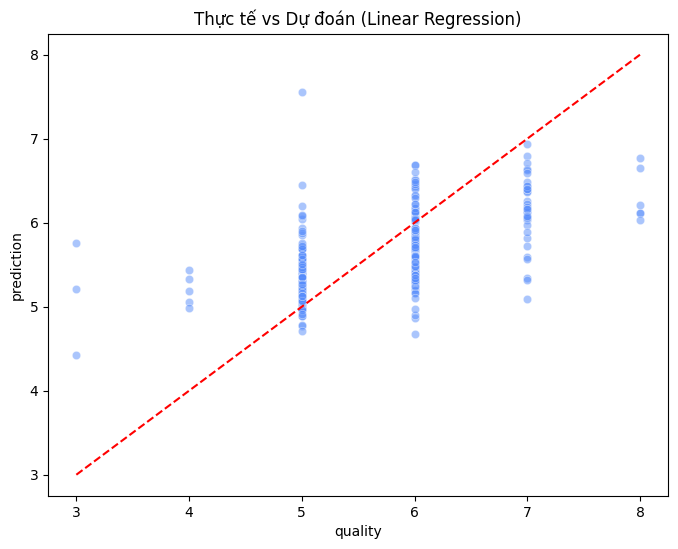

In [7]:
from pyspark.ml.evaluation import RegressionEvaluator

predictions_wine = lr_model.transform(test_data_wine)
evaluator_wine = RegressionEvaluator(labelCol="quality", predictionCol="prediction", metricName="rmse")
print(f"RMSE (Linear Regression): {evaluator_wine.evaluate(predictions_wine):.4f}")

pd_preds_wine = predictions_wine.select("quality", "prediction").toPandas()
plt.figure(figsize=(8, 6))
sns.scatterplot(x='quality', y='prediction', data=pd_preds_wine, alpha=0.5)
plt.plot([3, 8], [3, 8], color='red', linestyle='--') # Đường y = x
plt.title("Thực tế vs Dự đoán (Linear Regression)")
plt.show()